# 273. Integer to English Words
https://leetcode.com/problems/integer-to-english-words/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| **Divide and conquer (Optimal)** | **O(1)** | **O(1)** | Process 3-digit groups with scale words |

## Methodology

Process the number in groups of three digits (ones, thousands, millions, billions). For each group, convert the three-digit number to words using lookup arrays for ones, teens, and tens. Append the appropriate scale word (Thousand, Million, Billion) for each group. The input is bounded by 2^31 - 1, so at most 10 digits.

## Solutions

### C#

In [ ]:
public class Solution {
    private static readonly string[] ones = {"", "One", "Two", "Three", "Four", "Five", "Six", "Seven", "Eight", "Nine", "Ten",
        "Eleven", "Twelve", "Thirteen", "Fourteen", "Fifteen", "Sixteen", "Seventeen", "Eighteen", "Nineteen"};
    private static readonly string[] tens = {"", "", "Twenty", "Thirty", "Forty", "Fifty", "Sixty", "Seventy", "Eighty", "Ninety"};
    private static readonly string[] scales = {"", "Thousand", "Million", "Billion"};
    
    public string NumberToWords(int num) {
        if (num == 0) return "Zero";
        string result = "";
        int i = 0;
        while (num > 0) {
            int chunk = num % 1000;
            if (chunk != 0) {
                string s = Helper(chunk) + (scales[i] != "" ? " " + scales[i] : "");
                result = s + (result != "" ? " " + result : "");
            }
            num /= 1000;
            i++;
        }
        return result;
    }
    
    private string Helper(int num) {
        if (num == 0) return "";
        if (num < 20) return ones[num];
        if (num < 100) return tens[num / 10] + (num % 10 != 0 ? " " + ones[num % 10] : "");
        return ones[num / 100] + " Hundred" + (num % 100 != 0 ? " " + Helper(num % 100) : "");
    }
}

### Python

In [ ]:
class Solution:
    def numberToWords(self, num: int) -> str:
        if num == 0:
            return 'Zero'
        ones = ['', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine',
                'Ten', 'Eleven', 'Twelve', 'Thirteen', 'Fourteen', 'Fifteen', 'Sixteen',
                'Seventeen', 'Eighteen', 'Nineteen']
        tens_w = ['', '', 'Twenty', 'Thirty', 'Forty', 'Fifty', 'Sixty', 'Seventy', 'Eighty', 'Ninety']
        scales = ['', 'Thousand', 'Million', 'Billion']
        
        def helper(n):
            if n == 0: return ''
            if n < 20: return ones[n]
            if n < 100: return tens_w[n // 10] + (' ' + ones[n % 10] if n % 10 else '')
            return ones[n // 100] + ' Hundred' + (' ' + helper(n % 100) if n % 100 else '')
        
        parts = []
        i = 0
        while num:
            chunk = num % 1000
            if chunk:
                s = helper(chunk) + (' ' + scales[i] if scales[i] else '')
                parts.append(s)
            num //= 1000
            i += 1
        return ' '.join(reversed(parts))

### Go

In [ ]:
var (
    onesW  = []string{"", "One", "Two", "Three", "Four", "Five", "Six", "Seven", "Eight", "Nine",
        "Ten", "Eleven", "Twelve", "Thirteen", "Fourteen", "Fifteen", "Sixteen", "Seventeen", "Eighteen", "Nineteen"}
    tensW  = []string{"", "", "Twenty", "Thirty", "Forty", "Fifty", "Sixty", "Seventy", "Eighty", "Ninety"}
    scales = []string{"", "Thousand", "Million", "Billion"}
)

func numberToWords(num int) string {
    if num == 0 { return "Zero" }
    result := ""
    i := 0
    for num > 0 {
        chunk := num % 1000
        if chunk != 0 {
            s := helper(chunk)
            if scales[i] != "" { s += " " + scales[i] }
            if result != "" { s += " " + result }
            result = s
        }
        num /= 1000
        i++
    }
    return result
}

func helper(num int) string {
    if num == 0 { return "" }
    if num < 20 { return onesW[num] }
    if num < 100 {
        s := tensW[num/10]
        if num%10 != 0 { s += " " + onesW[num%10] }
        return s
    }
    s := onesW[num/100] + " Hundred"
    if num%100 != 0 { s += " " + helper(num%100) }
    return s
}

### Rust

In [ ]:
impl Solution {
    pub fn number_to_words(num: i32) -> String {
        if num == 0 { return "Zero".to_string(); }
        let ones = ["","One","Two","Three","Four","Five","Six","Seven","Eight","Nine",
            "Ten","Eleven","Twelve","Thirteen","Fourteen","Fifteen","Sixteen","Seventeen","Eighteen","Nineteen"];
        let tens = ["","","Twenty","Thirty","Forty","Fifty","Sixty","Seventy","Eighty","Ninety"];
        let scales = ["","Thousand","Million","Billion"];
        
        fn helper(n: i32, ones: &[&str], tens: &[&str]) -> String {
            if n == 0 { return String::new(); }
            if n < 20 { return ones[n as usize].to_string(); }
            if n < 100 {
                let s = tens[(n/10) as usize].to_string();
                return if n%10 != 0 { format!("{} {}", s, ones[(n%10) as usize]) } else { s };
            }
            let s = format!("{} Hundred", ones[(n/100) as usize]);
            if n%100 != 0 { format!("{} {}", s, helper(n%100, ones, tens)) } else { s }
        }
        
        let mut num = num;
        let mut parts = Vec::new();
        let mut i = 0;
        while num > 0 {
            let chunk = num % 1000;
            if chunk != 0 {
                let mut s = helper(chunk, &ones, &tens);
                if !scales[i].is_empty() { s = format!("{} {}", s, scales[i]); }
                parts.push(s);
            }
            num /= 1000;
            i += 1;
        }
        parts.reverse();
        parts.join(" ")
    }
}

## Example Scenarios

1. **Common Case**  
   **Input:** `num = 12345`  
   Groups: $12$ thousand, $345$. Result: `"Twelve Thousand Three Hundred Forty Five"`.

2. **Slightly Complex**  
   **Input:** `num = 1000010`  
   Groups: $1$ million, $0$ thousand (skipped), $10$. Result: `"One Million Ten"`. Middle zero group is omitted.

3. **Edge Case: Time Factor**  
   **Input:** `num = 2147483647` ($2^{31}-1$, maximum 32-bit integer).  
   Four groups processed: billions, millions, thousands, ones. Result: `"Two Billion One Hundred Forty Seven Million Four Hundred Eighty Three Thousand Six Hundred Forty Seven"`. Constant $O(1)$ time.

4. **Edge Case: Space Factor**  
   **Input:** `num = 0`  
   Special case returns `"Zero"` immediately. No recursive processing, minimal space.

5. **Almost-Impossible but Plausible**  
   **Input:** `num = 1000000000`  
   Exactly one billion, all lower groups are zero. Result: `"One Billion"`. Tests that trailing zero groups produce no extra spaces.

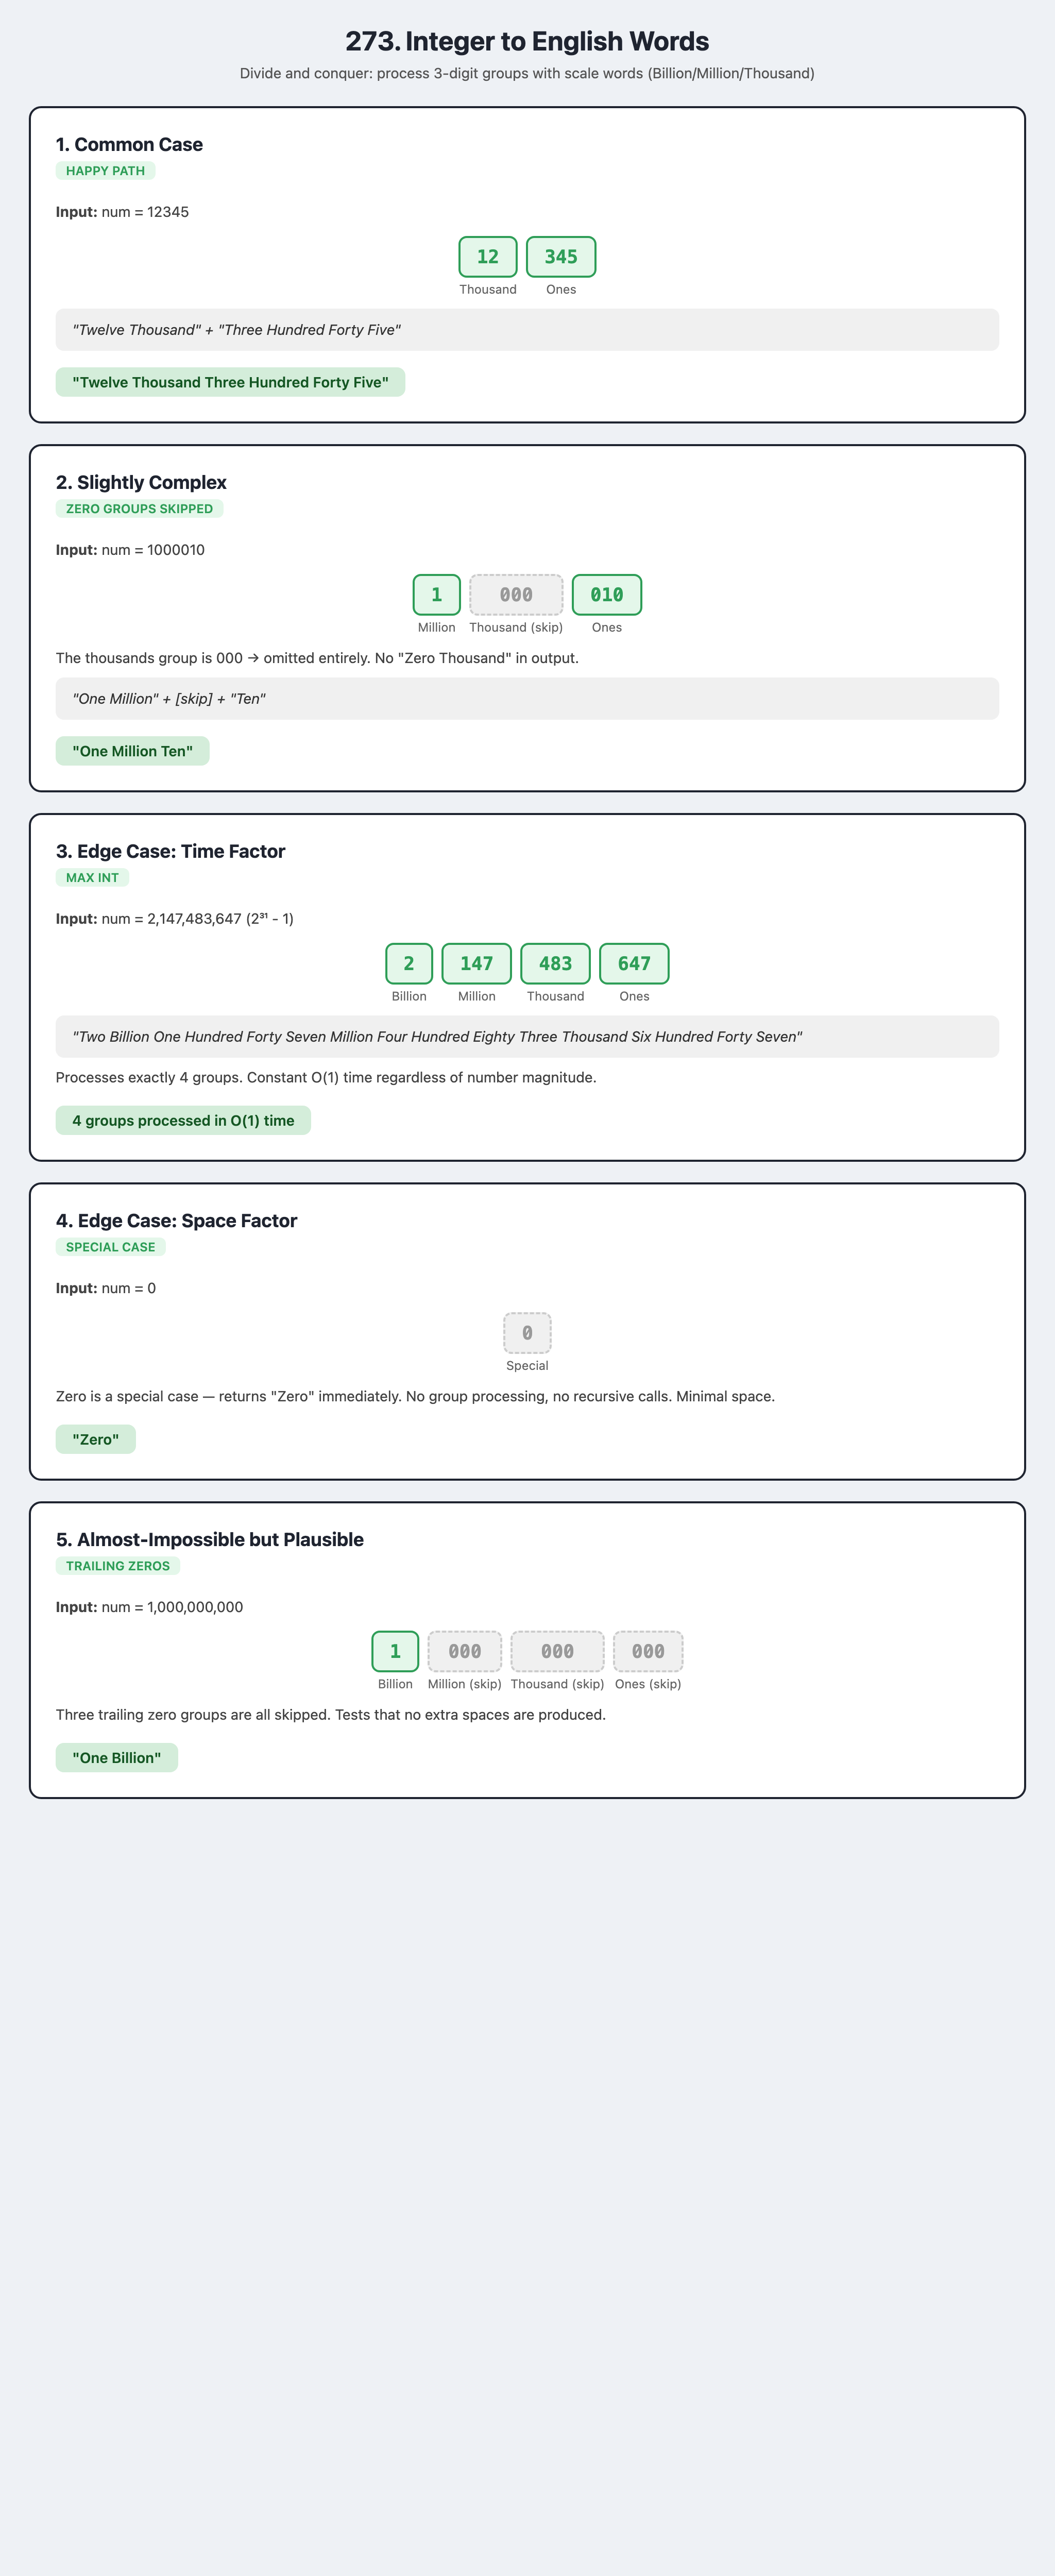